<a href="https://colab.research.google.com/github/ymuto0302/ML_Study_Session/blob/main/MLP_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 26.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=b43e3609bb5d00f7c1271bb6ef4d0a3d1b01d164ea19d7b1a731e77ae7e3b625
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib


## テンソル（Tensor）

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# テンソルの作成
x = torch.tensor([1.0, 2.0, 3.0])
print(f"テンソル: {x}, shape: {x.shape}, dtype: {x.dtype}")

# NumPy からの変換
arr = np.array([[1, 2], [3, 4]], dtype=np.float32)
t = torch.from_numpy(arr)
print(f"NumPy → Tensor: {t}")

# GPU が利用可能な場合
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用デバイス: {device}")


テンソル: tensor([1., 2., 3.]), shape: torch.Size([3]), dtype: torch.float32
NumPy → Tensor: tensor([[1., 2.],
        [3., 4.]])
使用デバイス: cpu


## 自動微分（autograd）

In [2]:
# 自動微分の基本例
w = torch.tensor([2.0], requires_grad=True)
b = torch.tensor([1.0], requires_grad=True)
x = torch.tensor([3.0])
y_true = torch.tensor([10.0])

# 順伝播
y_pred = w * x + b           # y_pred = 2*3 + 1 = 7
loss = (y_pred - y_true) ** 2  # loss = (7-10)² = 9

# 逆伝播（自動微分）
loss.backward()

print(f"y_pred = {y_pred.item():.1f}")
print(f"loss = {loss.item():.1f}")
print(f"∂loss/∂w = {w.grad.item():.1f}")  # 2*(7-10)*3 = -18
print(f"∂loss/∂b = {b.grad.item():.1f}")  # 2*(7-10)*1 = -6


y_pred = 7.0
loss = 9.0
∂loss/∂w = -18.0
∂loss/∂b = -6.0


## PyTorch の学習ループの基本形
（注意）以下は概念的なコードである。故にコメントで囲んである。

In [3]:
# PyTorch の典型的な学習ループ
"""
model = ...
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(n_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        # 1. 順伝播
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        # 2. 勾配の初期化
        optimizer.zero_grad()

        # 3. 逆伝播
        loss.backward()

        # 4. パラメータ更新
        optimizer.step()
"""


'\nmodel = ...\noptimizer = optim.Adam(model.parameters(), lr=0.001)\ncriterion = nn.CrossEntropyLoss()\n\nfor epoch in range(n_epochs):\n    model.train()\n    for X_batch, y_batch in train_loader:\n        # 1. 順伝播\n        outputs = model(X_batch)\n        loss = criterion(outputs, y_batch)\n\n        # 2. 勾配の初期化\n        optimizer.zero_grad()\n\n        # 3. 逆伝播\n        loss.backward()\n\n        # 4. パラメータ更新\n        optimizer.step()\n'

## 基本的な分類 ─ Iris データセット

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt

# ───────────────────────────
# データの準備
# ───────────────────────────
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# PyTorch テンソルに変換
X_train_t = torch.FloatTensor(X_train_sc)
y_train_t = torch.LongTensor(y_train)
X_test_t = torch.FloatTensor(X_test_sc)
y_test_t = torch.LongTensor(y_test)

# DataLoader の作成
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# ───────────────────────────
# モデルの定義
# ───────────────────────────
class IrisNet(nn.Module):
    def __init__(self, input_dim=4, hidden1=64, hidden2=32, output_dim=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, output_dim)
            # 注: Softmax は CrossEntropyLoss に含まれるため不要
        )

    def forward(self, x):
        return self.net(x)

model = IrisNet()
print(model)
print(f"\n総パラメータ数: {sum(p.numel() for p in model.parameters()):,}")

# ───────────────────────────
# 学習の設定
# ───────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# ───────────────────────────
# 学習ループ
# ───────────────────────────
n_epochs = 100
train_losses = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * len(X_batch)

    avg_loss = epoch_loss / len(train_dataset)
    train_losses.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1:3d}/{n_epochs}]  Loss: {avg_loss:.4f}")

# ───────────────────────────
# 評価
# ───────────────────────────
model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    y_pred = logits.argmax(dim=1).numpy()

print(f"\nテスト正解率: {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=iris.target_names))


IrisNet(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=3, bias=True)
  )
)

総パラメータ数: 2,499
Epoch [ 20/100]  Loss: 0.1577
Epoch [ 40/100]  Loss: 0.0529
Epoch [ 60/100]  Loss: 0.0327
Epoch [ 80/100]  Loss: 0.0226
Epoch [100/100]  Loss: 0.0169

テスト正解率: 0.9333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



## 学習曲線の可視化

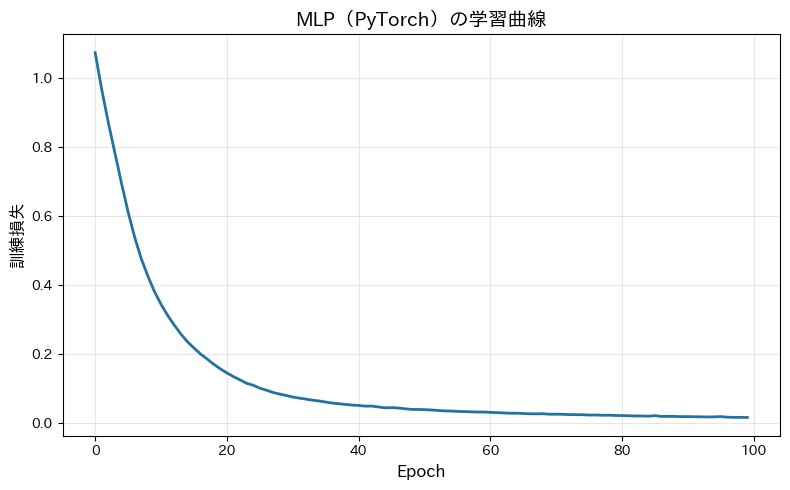

In [7]:
import japanize_matplotlib

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_losses, linewidth=2, color='#2471A3')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('訓練損失', fontsize=12)
ax.set_title('MLP（PyTorch）の学習曲線', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pytorch_mlp_loss.png', dpi=150)
plt.show()


## 確率出力の確認

In [8]:
model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    probs = torch.softmax(logits, dim=1).numpy()

print("サンプル  |  setosa   versicolor  virginica  | 予測     | 正解")
print("-" * 70)
for i in range(10):
    pred_name = iris.target_names[y_pred[i]]
    true_name = iris.target_names[y_test[i]]
    mark = "✓" if y_pred[i] == y_test[i] else "✗"
    print(f"  {i:3d}     | {probs[i,0]:.4f}    {probs[i,1]:.4f}     {probs[i,2]:.4f}   "
          f"| {pred_name:10s} | {true_name} {mark}")


サンプル  |  setosa   versicolor  virginica  | 予測     | 正解
----------------------------------------------------------------------
    0     | 0.0000    0.0002     0.9998   | virginica  | virginica ✓
    1     | 0.0004    0.9976     0.0020   | versicolor | versicolor ✓
    2     | 0.0003    0.9256     0.0741   | versicolor | virginica ✗
    3     | 0.0036    0.9856     0.0108   | versicolor | versicolor ✓
    4     | 0.0009    0.2290     0.7702   | virginica  | virginica ✓
    5     | 0.0000    0.0000     1.0000   | virginica  | virginica ✓
    6     | 0.0001    0.9983     0.0016   | versicolor | versicolor ✓
    7     | 0.0001    0.9998     0.0001   | versicolor | versicolor ✓
    8     | 0.9987    0.0013     0.0000   | setosa     | setosa ✓
    9     | 0.0000    0.0000     1.0000   | virginica  | virginica ✓


## 訓練・検証・テストを含む完全な学習ループ

Epoch  50: 訓練損失=0.2223, 検証損失=0.0976
Epoch 100: 訓練損失=0.1246, 検証損失=0.0538
早期停止: Epoch 110

最終テスト正解率: 0.9556


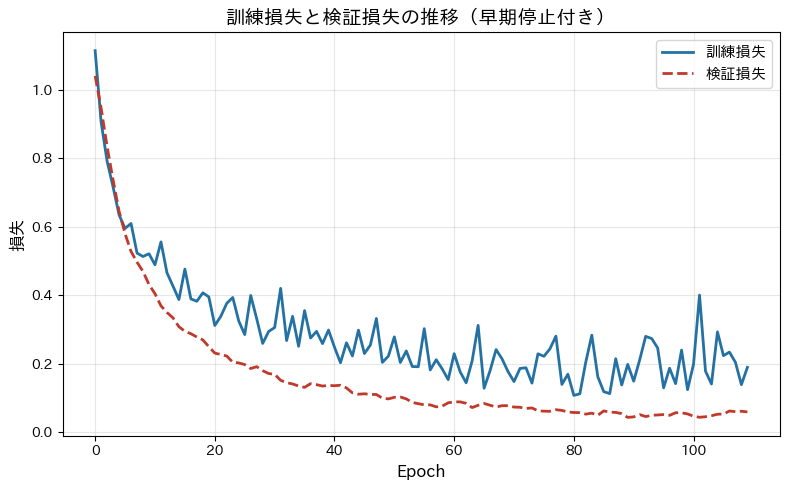

In [9]:
# ───────────────────────────
# 訓練データをさらに分割（訓練 + 検証）
# ───────────────────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sc, y_train, test_size=0.15, random_state=42, stratify=y_train
)

X_tr_t = torch.FloatTensor(X_tr)
y_tr_t = torch.LongTensor(y_tr)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.LongTensor(y_val)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_dl = DataLoader(train_ds, batch_size=16, shuffle=True)

# ───────────────────────────
# ドロップアウト・バッチ正規化付きモデル
# ───────────────────────────
class IrisNetRegularized(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 3)
        )

    def forward(self, x):
        return self.net(x)

model2 = IrisNetRegularized()
criterion2 = nn.CrossEntropyLoss()
optimizer2 = optim.Adam(model2.parameters(), lr=0.001, weight_decay=1e-4)

# ───────────────────────────
# 早期停止付き学習ループ
# ───────────────────────────
n_epochs = 300
patience = 20
best_val_loss = float('inf')
patience_counter = 0
best_state = None

train_history = []
val_history = []

for epoch in range(n_epochs):
    # 訓練フェーズ
    model2.train()
    epoch_loss = 0.0
    for X_b, y_b in train_dl:
        out = model2(X_b)
        loss = criterion2(out, y_b)
        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()
        epoch_loss += loss.item() * len(X_b)
    train_loss = epoch_loss / len(train_ds)
    train_history.append(train_loss)

    # 検証フェーズ
    model2.eval()
    with torch.no_grad():
        val_out = model2(X_val_t)
        val_loss = criterion2(val_out, y_val_t).item()
    val_history.append(val_loss)

    # 早期停止の判定
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = model2.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早期停止: Epoch {epoch+1}")
            break

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}: 訓練損失={train_loss:.4f}, 検証損失={val_loss:.4f}")

# 最良モデルを復元
model2.load_state_dict(best_state)

# 最終評価
model2.eval()
with torch.no_grad():
    test_out = model2(X_test_t)
    y_pred2 = test_out.argmax(dim=1).numpy()
print(f"\n最終テスト正解率: {accuracy_score(y_test, y_pred2):.4f}")

# 学習曲線のプロット
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_history, linewidth=2, color='#2471A3', label='訓練損失')
ax.plot(val_history, linewidth=2, color='#C0392B', linestyle='--', label='検証損失')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('損失', fontsize=12)
ax.set_title('訓練損失と検証損失の推移（早期停止付き）', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pytorch_early_stopping.png', dpi=150)
plt.show()


## 重みの可視化 ─ 学習された表現の観察

=== 第 1 層の重み行列 ===
形状: (64, 4) (64 ニューロン × 4 入力特徴量)
重みの統計: 平均=-0.0265, 標準偏差=0.3458
            最小=-0.6592, 最大=0.7410


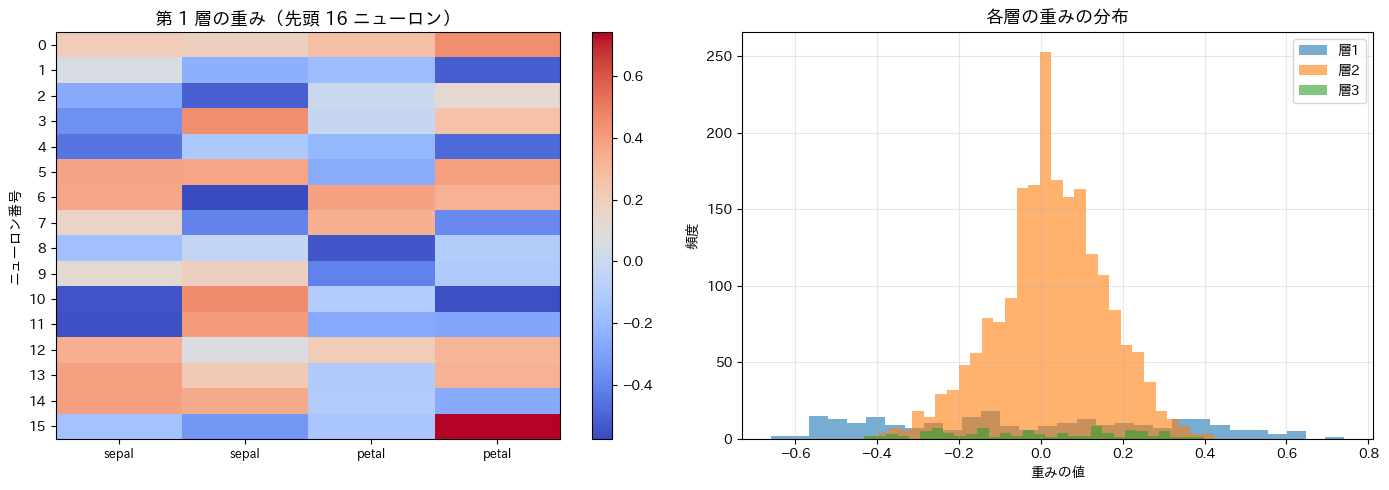

In [10]:
# 第 1 層の重みを可視化
W1 = model.net[0].weight.data.numpy()  # (64, 4)
b1 = model.net[0].bias.data.numpy()    # (64,)

print("=== 第 1 層の重み行列 ===")
print(f"形状: {W1.shape} (64 ニューロン × 4 入力特徴量)")
print(f"重みの統計: 平均={W1.mean():.4f}, 標準偏差={W1.std():.4f}")
print(f"            最小={W1.min():.4f}, 最大={W1.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 重み行列のヒートマップ
im = axes[0].imshow(W1[:16, :], cmap='coolwarm', aspect='auto')
axes[0].set_yticks(range(16))
axes[0].set_xticks(range(4))
axes[0].set_xticklabels([n.split(' ')[0] for n in iris.feature_names], fontsize=9)
axes[0].set_ylabel('ニューロン番号')
axes[0].set_title('第 1 層の重み（先頭 16 ニューロン）', fontsize=13)
plt.colorbar(im, ax=axes[0])

# 重みの分布（ヒストグラム）
for i, (W, name) in enumerate(zip(model.net[::2], ['層1', '層2', '層3'])):
    if hasattr(W, 'weight'):
        axes[1].hist(W.weight.data.numpy().ravel(), bins=30, alpha=0.6, label=name)
axes[1].set_xlabel('重みの値')
axes[1].set_ylabel('頻度')
axes[1].set_title('各層の重みの分布', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pytorch_weights.png', dpi=150)
plt.show()


## 決定境界の可視化

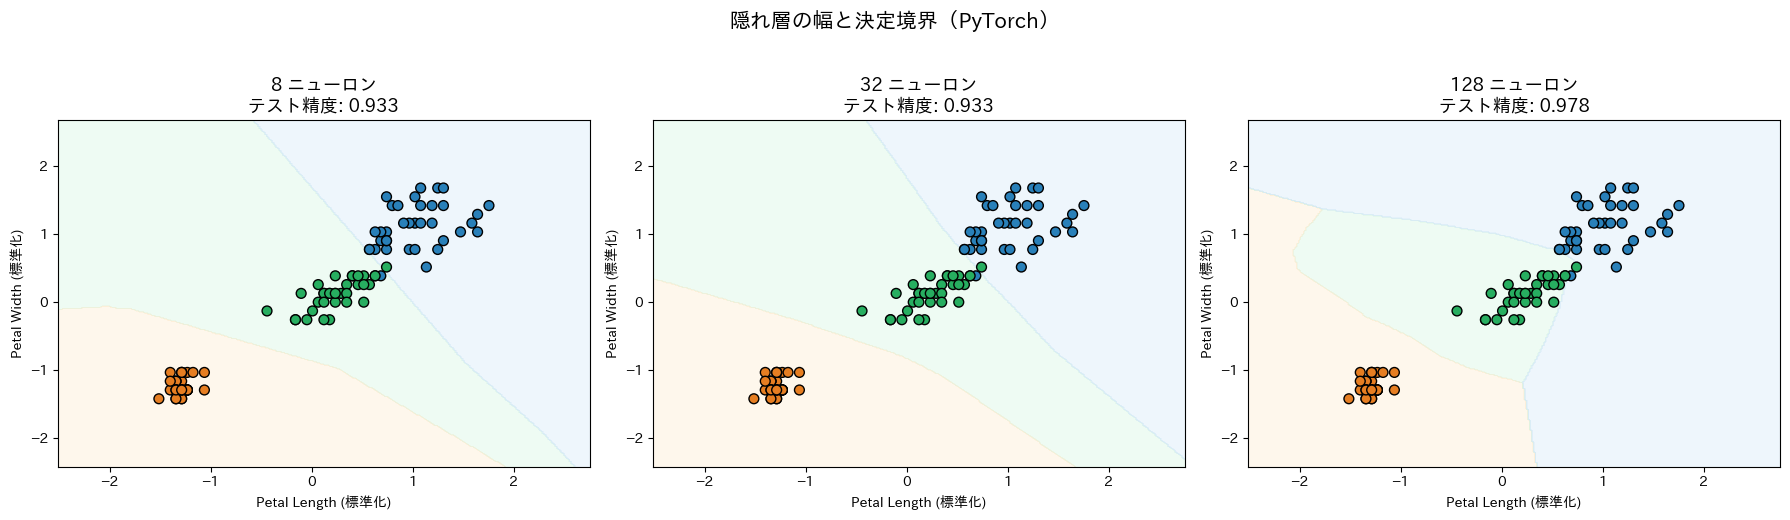

In [11]:
from matplotlib.colors import ListedColormap

X_vis = iris.data[:, 2:4]
y_vis = iris.target

X_tr_v, X_te_v, y_tr_v, y_te_v = train_test_split(
    X_vis, y_vis, test_size=0.3, random_state=42, stratify=y_vis
)
sc_v = StandardScaler()
X_tr_v_sc = sc_v.fit_transform(X_tr_v)
X_te_v_sc = sc_v.transform(X_te_v)

# 2 入力用モデルの定義と学習
class SmallNet(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, 3)
        )
    def forward(self, x):
        return self.net(x)

x_min, x_max = X_tr_v_sc[:, 0].min() - 1, X_tr_v_sc[:, 0].max() + 1
y_min, y_max = X_tr_v_sc[:, 1].min() - 1, X_tr_v_sc[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

cmap_bg = ListedColormap(['#FDEBD0', '#D5F5E3', '#D6EAF8'])
cmap_pt = ListedColormap(['#E67E22', '#27AE60', '#2980B9'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
configs = [('8 ニューロン', 8), ('32 ニューロン', 32), ('128 ニューロン', 128)]

Xt = torch.FloatTensor(X_tr_v_sc)
yt = torch.LongTensor(y_tr_v)

for ax, (name, h) in zip(axes, configs):
    net = SmallNet(h)
    opt = optim.Adam(net.parameters(), lr=0.01)
    crit = nn.CrossEntropyLoss()

    net.train()
    for _ in range(500):
        opt.zero_grad()
        crit(net(Xt), yt).backward()
        opt.step()

    net.eval()
    with torch.no_grad():
        grid_t = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
        Z = net(grid_t).argmax(dim=1).numpy().reshape(xx.shape)
        acc = (net(torch.FloatTensor(X_te_v_sc)).argmax(1).numpy() == y_te_v).mean()

    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
    ax.scatter(X_tr_v_sc[:, 0], X_tr_v_sc[:, 1], c=y_tr_v, cmap=cmap_pt,
               edgecolors='k', s=50)
    ax.set_title(f'{name}\nテスト精度: {acc:.3f}', fontsize=13)
    ax.set_xlabel('Petal Length (標準化)')
    ax.set_ylabel('Petal Width (標準化)')

plt.suptitle('隠れ層の幅と決定境界（PyTorch）', fontsize=15, y=1.03)
plt.tight_layout()
plt.savefig('pytorch_decision_boundary.png', dpi=150)
plt.show()


## 学習率の影響の比較

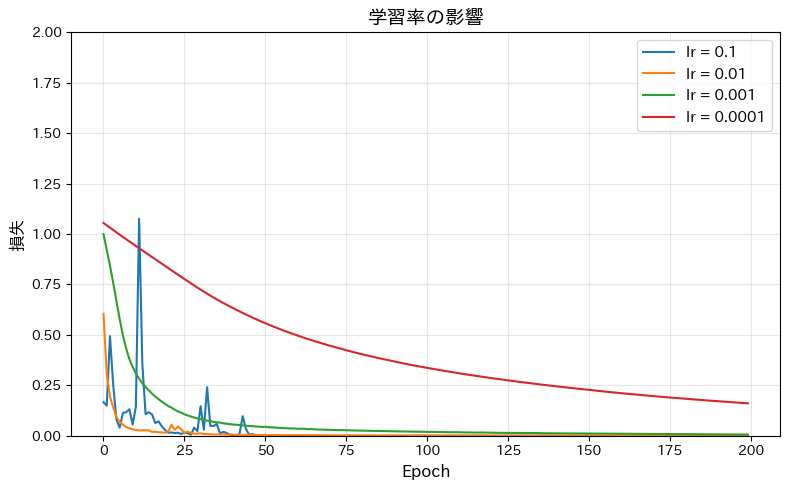

In [12]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]

fig, ax = plt.subplots(figsize=(8, 5))

for lr in learning_rates:
    net_lr = IrisNet()
    opt_lr = optim.Adam(net_lr.parameters(), lr=lr)
    crit_lr = nn.CrossEntropyLoss()

    losses = []
    for epoch in range(200):
        net_lr.train()
        for Xb, yb in train_loader:
            opt_lr.zero_grad()
            crit_lr(net_lr(Xb), yb).backward()
            opt_lr.step()
        net_lr.eval()
        with torch.no_grad():
            losses.append(crit_lr(net_lr(X_train_t), y_train_t).item())

    ax.plot(losses, linewidth=1.5, label=f'lr = {lr}')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('損失', fontsize=12)
ax.set_title('学習率の影響', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(0, 2.0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pytorch_learning_rate.png', dpi=150)
plt.show()


## XOR 問題 ─ 線形分離不可能問題の解決

=== XOR 問題 ===

入力          正解  線形  MLP
[0. 0.]   0     0     0
[0. 1.]   1     0     1
[1. 0.]   1     0     1
[1. 1.]   0     0     0


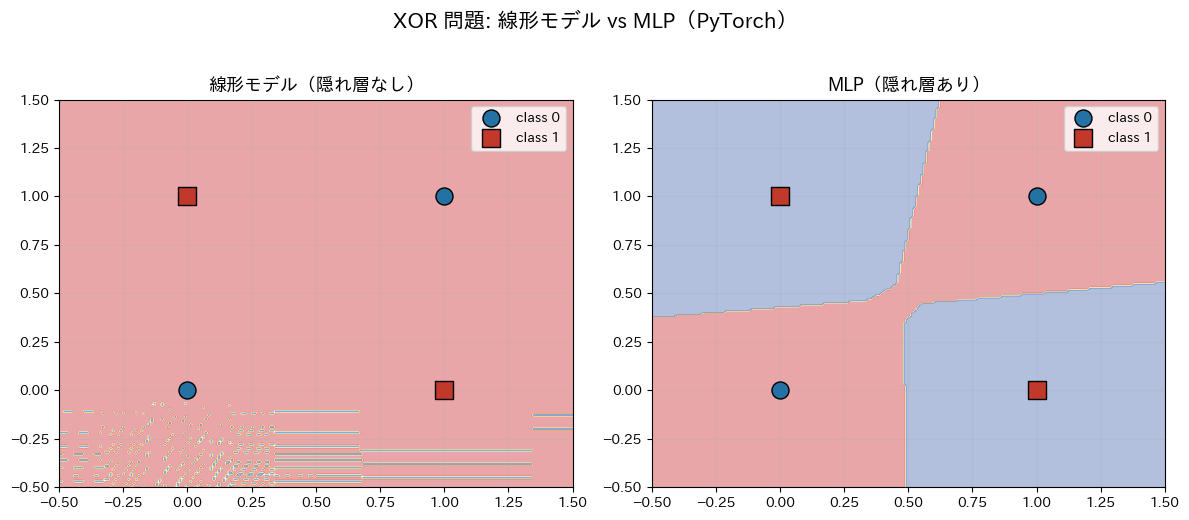

In [13]:
# XOR データ
X_xor = torch.FloatTensor([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = torch.LongTensor([0, 1, 1, 0])

# 線形モデル（隠れ層なし）
linear_model = nn.Linear(2, 2)
opt_lin = optim.Adam(linear_model.parameters(), lr=0.01)

# MLP（隠れ層あり）
mlp_model = nn.Sequential(
    nn.Linear(2, 8), nn.ReLU(),
    nn.Linear(8, 2)
)
opt_mlp = optim.Adam(mlp_model.parameters(), lr=0.01)

criterion_xor = nn.CrossEntropyLoss()

# 学習
for ep in range(2000):
    opt_lin.zero_grad()
    criterion_xor(linear_model(X_xor), y_xor).backward()
    opt_lin.step()

    opt_mlp.zero_grad()
    criterion_xor(mlp_model(X_xor), y_xor).backward()
    opt_mlp.step()

linear_model.eval()
mlp_model.eval()
with torch.no_grad():
    pred_lin = linear_model(X_xor).argmax(1).numpy()
    pred_mlp = mlp_model(X_xor).argmax(1).numpy()

print("=== XOR 問題 ===\n")
print(f"入力          正解  線形  MLP")
for i in range(4):
    print(f"{X_xor[i].numpy()}   {y_xor[i].item()}     {pred_lin[i]}     {pred_mlp[i]}")

# 決定境界の可視化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
xx_xor, yy_xor = np.meshgrid(
    np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200)
)
grid_xor = torch.FloatTensor(np.c_[xx_xor.ravel(), yy_xor.ravel()])

for ax, mdl, name in [(axes[0], linear_model, '線形モデル（隠れ層なし）'),
                        (axes[1], mlp_model, 'MLP（隠れ層あり）')]:
    with torch.no_grad():
        Z = mdl(grid_xor).argmax(1).numpy().reshape(xx_xor.shape)
    ax.contourf(xx_xor, yy_xor, Z, alpha=0.4, cmap='RdYlBu')
    for cls, marker, color in [(0, 'o', '#2471A3'), (1, 's', '#C0392B')]:
        mask = y_xor.numpy() == cls
        ax.scatter(X_xor[mask, 0], X_xor[mask, 1], marker=marker,
                   color=color, s=150, edgecolors='k', zorder=5, label=f'class {cls}')
    ax.set_title(name, fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('XOR 問題: 線形モデル vs MLP（PyTorch）', fontsize=15, y=1.03)
plt.tight_layout()
plt.savefig('pytorch_xor.png', dpi=150)
plt.show()


## カスタム Dataset ─ 実データへの応用テンプレート

In [14]:
from torch.utils.data import Dataset

class CustomDataset(Dataset):
    """任意の NumPy データを PyTorch Dataset として扱うテンプレート"""
    def __init__(self, X, y, transform=None):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.transform:
            x = self.transform(x)
        return x, self.y[idx]

# 使用例
train_ds_custom = CustomDataset(X_train_sc, y_train)
train_dl_custom = DataLoader(train_ds_custom, batch_size=32, shuffle=True)

print(f"データセットサイズ: {len(train_ds_custom)}")
x_sample, y_sample = train_ds_custom[0]
print(f"サンプル: x.shape={x_sample.shape}, y={y_sample.item()}")


データセットサイズ: 105
サンプル: x.shape=torch.Size([4]), y=1


## モデルの保存と読み込み

In [15]:
# モデルの保存
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': n_epochs,
    'loss': train_losses[-1],
}, 'iris_mlp_checkpoint.pt')

# モデルの読み込み
checkpoint = torch.load('iris_mlp_checkpoint.pt', weights_only=False)
model_loaded = IrisNet()
model_loaded.load_state_dict(checkpoint['model_state_dict'])
model_loaded.eval()

with torch.no_grad():
    y_pred_loaded = model_loaded(X_test_t).argmax(dim=1).numpy()
print(f"読み込んだモデルの精度: {accuracy_score(y_test, y_pred_loaded):.4f}")


読み込んだモデルの精度: 0.9333
